**THE OBJECIVE OF THIS PROJECT IS TO Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risks**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\N yugesh\Downloads\ecommerce_customer_data_custom_ratios.csv

1. LOADING THE DATA

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


2. Handaling Missing and Duplicate values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [7]:
df.dropna(inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

NO DUPLICATES

In [10]:
df['Total_Spending'] = df['Quantity'] * df['Product Price']

In [12]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

df['Month'] = df['Purchase Date'].dt.month

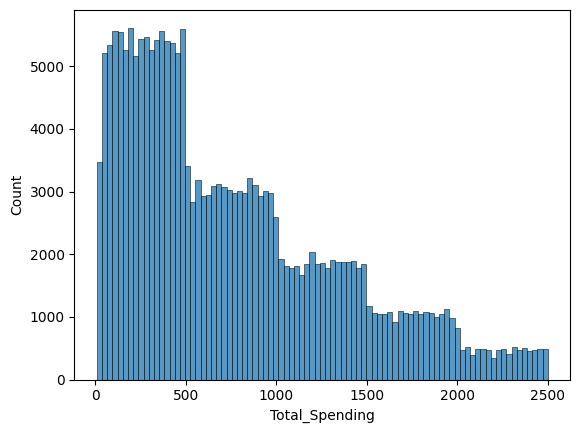

In [13]:
sns.histplot(df['Total_Spending'])
plt.show()

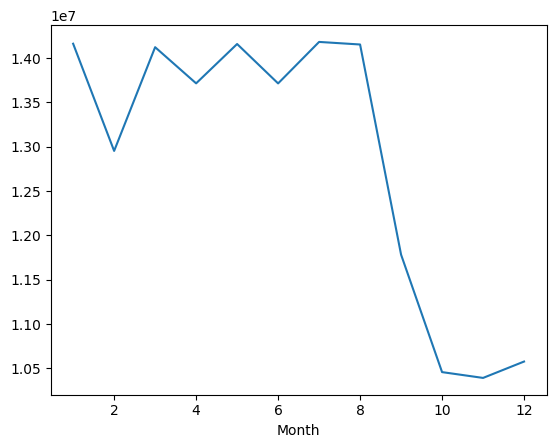

In [14]:
monthly_sales = df.groupby('Month')['Total_Spending'].sum()

monthly_sales.plot(kind='line')
plt.show()

In [18]:
latest_date = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Product Category': 'count',
    'Total_Spending': 'sum'
})

In [19]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [20]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,845
2,298,2,678
3,88,7,4591
4,585,1,276
5,170,6,3976


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [23]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,219.903436,2.755764,1725.817447
1,211.275222,4.842594,3715.216455
2,158.937111,7.198464,6280.625579
3,796.420580,2.327468,1702.033679


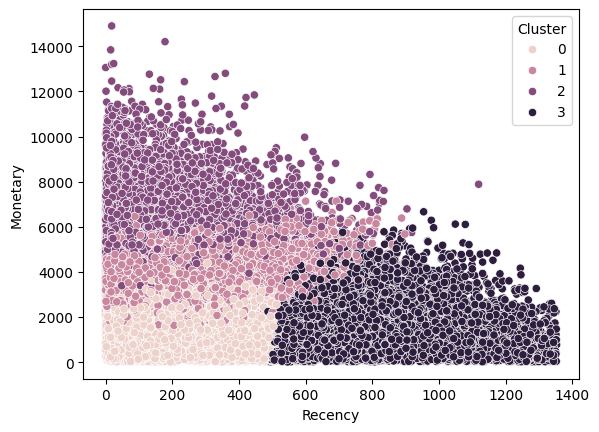

In [24]:
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster']
)

plt.show()

In [25]:
rfm['Churn_Risk'] = np.where(rfm['Recency'] > 90, "High", "Low")

**Recomendations**
1. Reward Loyal Customers
Give discounts and loyalty points.

2. Re-engage Inactive Customers
Send email offers.

3. Personalized Recommendations
Recommend products based on past purchases.

4. Seasonal Campaigns
Promote products during peak sales months.

5. Reduce Churn
Target inactive customers with special deals.


**CONCLUSION**

The analysis identified multiple customer groups based on purchase behavior. Loyal customers generated high revenue, while some customers showed churn risk. Business recommendations were proposed to improve retention and customer engagement.